In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,SimpleRNN, Bidirectional, BatchNormalization
import os
os.getcwd()

'/content'

# Loading The Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/CMaps/train_FD001.txt", sep=r"\s+", header=None)
test  = pd.read_csv("/content/drive/MyDrive/CMaps/test_FD001.txt", sep=r"\s+", header=None)
rul   = pd.read_csv("/content/drive/MyDrive/CMaps/RUL_FD001.txt", header=None)

cols = ["engine_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

train.columns = cols
test.columns  = cols
rul.columns   = ["RUL"]

In [ ]:
max_cycle = train.groupby("engine_id")["cycle"].max()
train["RUL"] = train["engine_id"].map(max_cycle) - train["cycle"]

#EDA

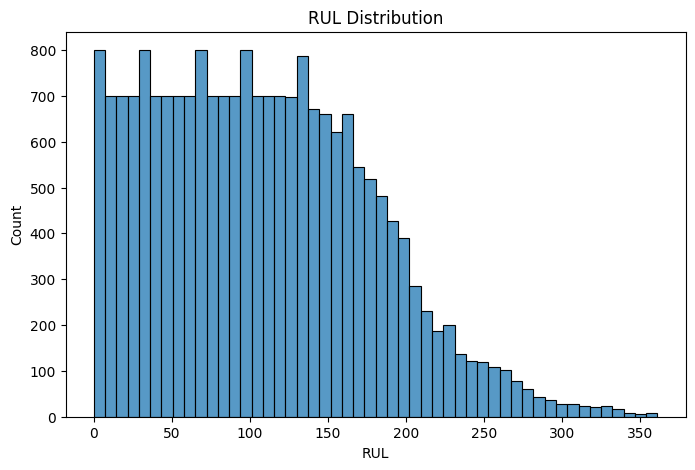

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train["RUL"], bins=50)
plt.title("RUL Distribution")
plt.show()

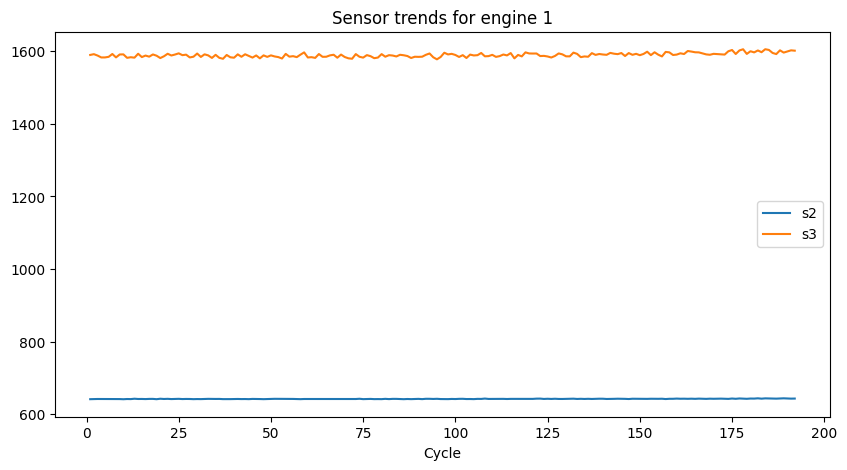

In [ ]:
engine = 1
df = train[train["engine_id"] == engine]

plt.figure(figsize=(10,5))
plt.plot(df["cycle"], df["s2"], label="s2")
plt.plot(df["cycle"], df["s3"], label="s3")
plt.legend()
plt.title(f"Sensor trends for engine {engine}")
plt.xlabel("Cycle")
plt.show()

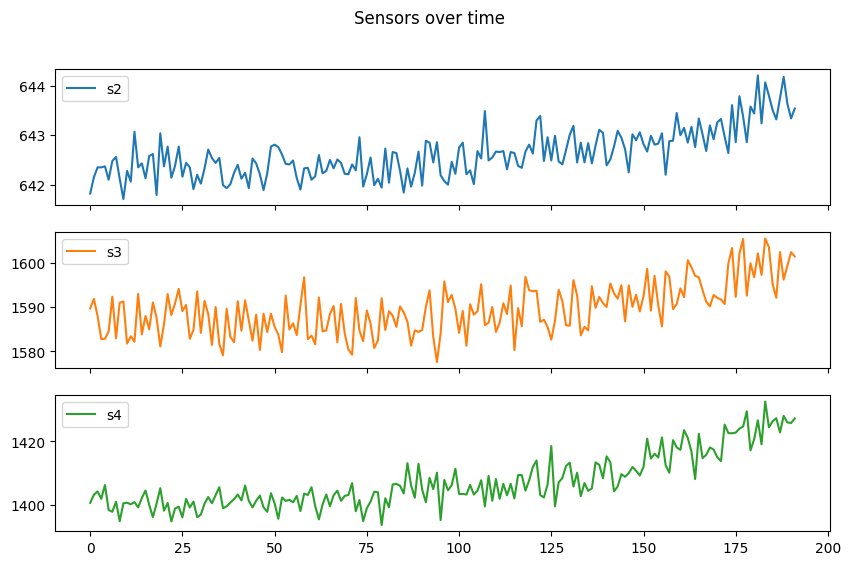

In [ ]:
sensors = ["s2", "s3", "s4"]

df = train[train["engine_id"] == 1]

df[sensors].plot(subplots=True, figsize=(10,6), title="Sensors over time")
plt.show()

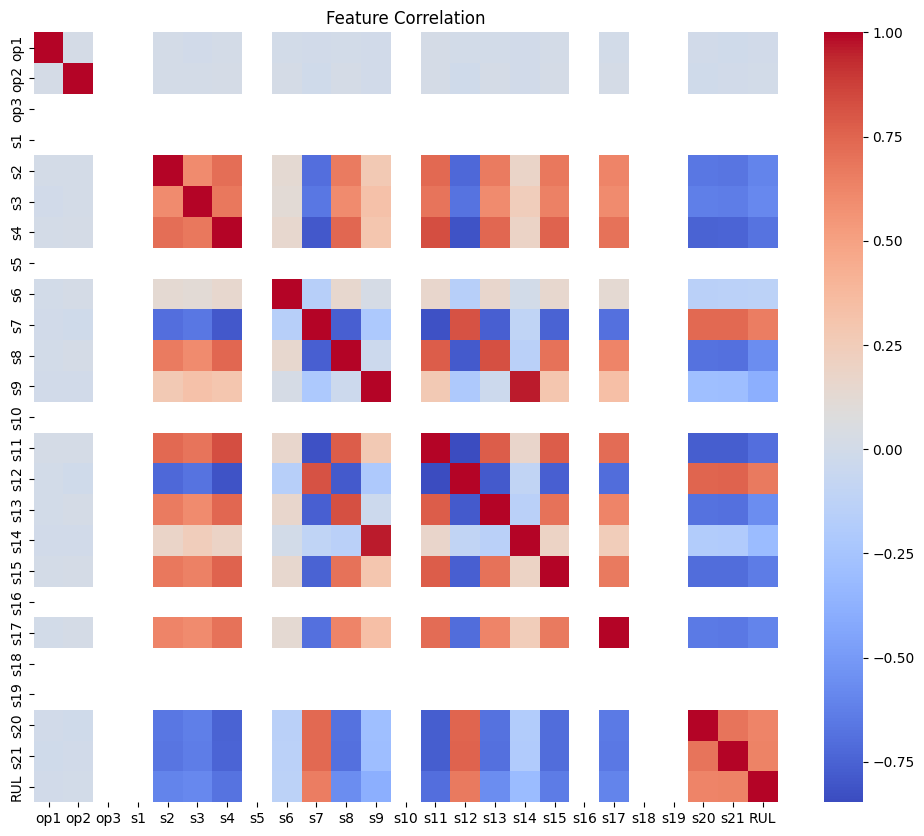

In [ ]:
plt.figure(figsize=(12,10))
corr = train.drop(columns=["engine_id", "cycle"]).corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [ ]:
corr_with_rul = train.corr()["RUL"].sort_values()

print(corr_with_rul)

cycle       -0.736241
s11         -0.696228
s4          -0.678948
s15         -0.642667
s2          -0.606484
s17         -0.606154
s3          -0.584520
s8          -0.563968
s13         -0.562569
s9          -0.390102
s14         -0.306769
s6          -0.128348
op1         -0.003198
op2         -0.001948
engine_id    0.078753
s20          0.629428
s21          0.635662
s7           0.657223
s12          0.671983
RUL          1.000000
op3               NaN
s1                NaN
s5                NaN
s10               NaN
s16               NaN
s18               NaN
s19               NaN
Name: RUL, dtype: float64


In [ ]:
std = train.std()
low_variance = std[std < 0.01]

print("Low variance features:")
print(low_variance)

Low variance features:
op1    2.187313e-03
op2    2.930621e-04
op3    0.000000e+00
s1     6.537152e-11
s5     3.394700e-12
s6     1.388985e-03
s10    4.660829e-13
s16    1.556432e-14
s18    0.000000e+00
s19    0.000000e+00
dtype: float64


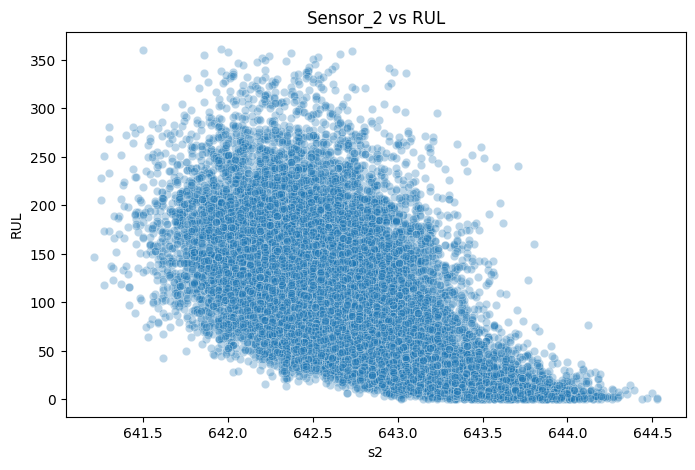

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=train["s2"], y=train["RUL"], alpha=0.3)
plt.title("Sensor_2 vs RUL")
plt.show()

/tmp/ipykernel_9961/3683239221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sensor_2_smooth"] = df["s2"].rolling(5).mean()


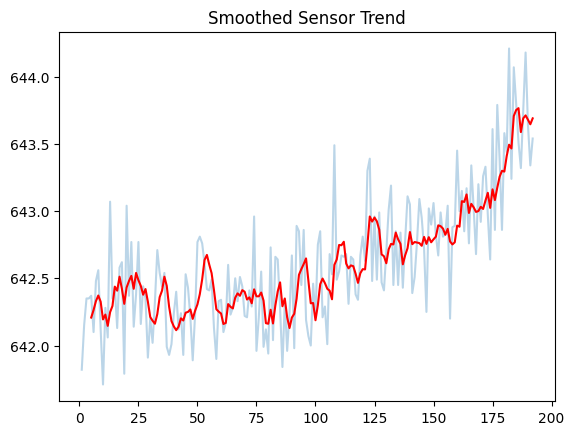

In [ ]:
df = train[train["engine_id"] == 1]

df["sensor_2_smooth"] = df["s2"].rolling(5).mean()

plt.plot(df["cycle"], df["s2"], alpha=0.3)
plt.plot(df["cycle"], df["sensor_2_smooth"], color="red")
plt.title("Smoothed Sensor Trend")
plt.show()

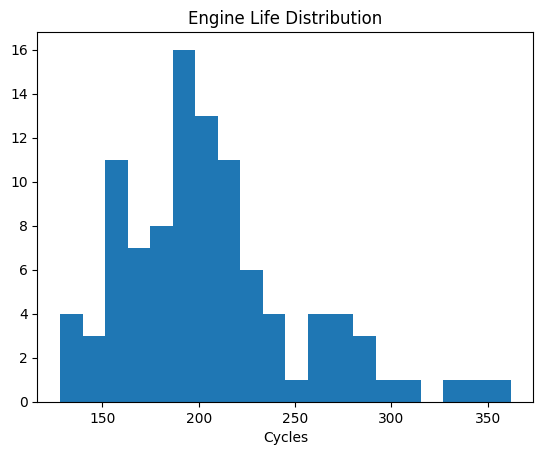

In [ ]:
engine_life = train.groupby("engine_id")["cycle"].max()

plt.hist(engine_life, bins=20)
plt.title("Engine Life Distribution")
plt.xlabel("Cycles")
plt.show()

#Preprocessing

In [ ]:
train["RUL"] = train["RUL"].clip(upper=125)

In [ ]:
features = [c for c in train.columns if c not in ["engine_id", "cycle", "RUL","op1","op2","op3","s1","s5","s6","s10","s16","s18","s19"]]

scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])
test[features]  = scaler.transform(test[features])

In [ ]:
def create_train_sequences(df, seq_length=30):
    X, y = [], []

    for engine in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine]

        for i in range(len(engine_data) - seq_length):
            seq = engine_data.iloc[i:i+seq_length][features].values
            target = engine_data.iloc[i+seq_length-1]["RUL"]

            X.append(seq)
            y.append(target)

    return np.array(X), np.array(y)


X_train, y_train = create_train_sequences(train, seq_length=30)

print("Train:", X_train.shape, y_train.shape)

Train: (17631, 30, 14) (17631,)


In [ ]:
def create_test_sequences(df, seq_length=30):
    X = []

    for engine in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine]


        seq = engine_data.iloc[-seq_length:][features].values

        X.append(seq)

    return np.array(X)


X_test = create_test_sequences(test, seq_length=30)

print("Test:", X_test.shape)

Test: (100, 30, 14)


In [ ]:
y_test = []

for i, engine in enumerate(test["engine_id"].unique()):
    engine_data = test[test["engine_id"] == engine]

    last_cycle = engine_data["cycle"].max()
    true_rul   = rul.iloc[i]["RUL"]


    y_test.append(true_rul)

y_test = np.array(y_test)

print("y_test shape:", y_test.shape)

y_test shape: (100,)


#Model

LSTM

In [ ]:
model = Sequential()

    # 🔥 Layer 1 (BiLSTM)
model.add(Bidirectional(
        LSTM(117, return_sequences=True),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
model.add(BatchNormalization())
model.add(Dropout(0.3829042359273979))

    # 🔥 Layer 2
model.add(Bidirectional(LSTM(45)))
model.add(BatchNormalization())
model.add(Dropout(0.3829042359273979))

    # 🔥 Dense layers (important!)
model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3829042359273979))

model.add(Dense(1))

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.0003675361439899416),
    loss="mse"
)

model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 60s 113ms/step - loss: 4454.6743 - val_loss: 1554.3011
Epoch 2/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - loss: 1193.6853 - val_loss: 543.4338
Epoch 3/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - loss: 1058.6921 - val_loss: 1417.6331
Epoch 4/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 49s 112ms/step - loss: 953.2920 - val_loss: 251.4636
Epoch 5/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - loss: 932.2776 - val_loss: 368.6118
Epoch 6/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - loss: 859.6647 - val_loss: 276.3141
Epoch 7/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 48s 108ms/step - loss: 829.7159 - val_loss: 700.7540
Epoch 8/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 51s 115ms/step - loss: 782.0839 - val_loss: 354.1451
Epoch 9/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step - loss: 743.4968 - val_loss: 219.8090
Epoch 10/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 48s 110ms/step - loss: 708.7611 - val_loss: 293.7954
Epoch 11/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - loss: 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 234)        │       123,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 234)        │           936 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 234)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 90)             │       100,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90)             │           360 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,485 (2.61 MB)

 Trainable params: 227,945 (890.41 KB)

 Non-trainable params: 648 (2.53 KB)

 Optimizer params: 455,892 (1.74 MB)

RNN

In [ ]:
model1 = Sequential()

model1.add(SimpleRNN(88, return_sequences=True, recurrent_dropout=0.0018545738825673508,
               input_shape=(X_train.shape[1], X_train.shape[2])))
model1.add(Dropout(0.26987891720143886))

model1.add(SimpleRNN(47,recurrent_dropout=0.0018545738825673508))
model1.add(Dropout(0.26987891720143886))

model1.add(Dense(32, activation="relu"))
model1.add(Dense(1))

model1.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse"
)

model1.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 7112.7939 - val_loss: 6821.8062
Epoch 2/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 5254.4478 - val_loss: 4764.1948
Epoch 3/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 3444.8667 - val_loss: 3079.5681
Epoch 4/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 2308.0823 - val_loss: 2164.7510
Epoch 5/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 1866.6702 - val_loss: 1859.5758
Epoch 6/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1765.9277 - val_loss: 1791.4879
Epoch 7/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 1758.0574 - val_loss: 1775.4124
Epoch 8/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1761.8651 - val_loss: 1775.0677
Epoch 9/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 1676.3553 - val_loss: 1004.1069
Epoch 10/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 612.2658 - val_loss: 405.3239
Epoch 11/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 4

In [ ]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 88)         │         9,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 88)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 47)             │         6,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,077 (199.52 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,052 (133.02 KB)

Transformers

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def positional_encoding(seq_len, d_model):
    pos = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
    i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]

    angle_rates = 1 / tf.pow(10000.0, (2 * (i//2)) / tf.cast(d_model, tf.float32))
    angle_rads = pos * angle_rates

    sines = tf.sin(angle_rads[:, 0::2])
    cosines = tf.cos(angle_rads[:, 1::2])

    pos_encoding = tf.concat([sines, cosines], axis=-1)
    return pos_encoding

def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0.2):

    # Multi-head attention
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feedforward
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(inputs.shape[-1])(ff)

    x = layers.Dropout(dropout)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)


def build_transformer_model(input_shape):

    inputs = layers.Input(shape=input_shape)

    # Positional encoding
    pos_encoding = positional_encoding(input_shape[0], input_shape[1])
    x = inputs + pos_encoding

    # Transformer blocks
    x = transformer_block(x, head_size=64, num_heads=4, ff_dim=128)
    x = transformer_block(x, head_size=64, num_heads=4, ff_dim=128)

    # Global pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
model2 = build_transformer_model((X_train.shape[1], X_train.shape[2]))

model2.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 14)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 14)    │     15,118 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 14)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 14)    │          0 │ dropout_6[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 14)    │         28 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 128)   │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30, 14)    │      1,806 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 14)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 14)    │          0 │ dropout_7[0][0],  │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 14)    │         28 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 14)    │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 30, 14)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 14)    │          0 │ dropout_9[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 14)    │         28 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 128)   │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 14)    │      1,806 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 14)    │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 14)    │          0 │ dropout_10[0][0], │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 38,825 (151.66 KB)

 Trainable params: 38,825 (151.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - loss: 3565.7397 - mae: 49.0397 - val_loss: 800.9402 - val_mae: 23.9235
Epoch 2/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - loss: 572.7910 - mae: 18.6628 - val_loss: 345.0036 - val_mae: 14.3746
Epoch 3/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 464.6461 - mae: 16.3815 - val_loss: 311.5480 - val_mae: 13.4227
Epoch 4/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 407.6624 - mae: 15.3878 - val_loss: 302.7366 - val_mae: 12.8779
Epoch 5/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - loss: 379.6536 - mae: 14.8228 - val_loss: 272.4795 - val_mae: 12.1740
Epoch 6/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - loss: 357.1953 - mae: 14.2817 - val_loss: 240.0000 - val_mae: 11.3063
Epoch 7/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - loss: 349.8369 - mae: 14.0980 - val_loss: 240.2464 - val_mae: 10.9700
Epoch 8/40
441/441 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 328.1152 - mae: 13.5385 - val_loss: 237.3281 - val_mae:

#Testing

LSTM

In [ ]:
pred = model.predict(X_test)
pred = pred.flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step


In [ ]:
for i in range(5):
    print(f"Predicted: {pred[i]:.2f}, Actual: {y_test[i]}")

Predicted: 97.81, Actual: 112
Predicted: 123.91, Actual: 98
Predicted: 62.26, Actual: 69
Predicted: 102.72, Actual: 82
Predicted: 114.13, Actual: 91


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("LSTM RMSE:", rmse)

LSTM RMSE: 17.53344930361456


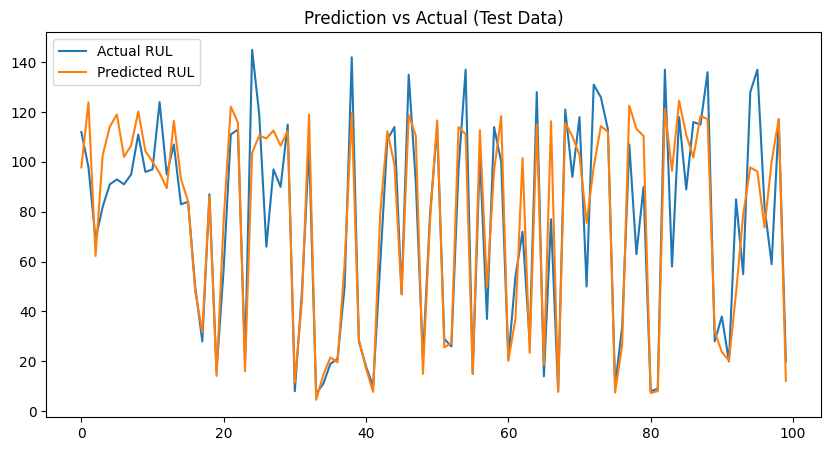

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual RUL")
plt.plot(pred, label="Predicted RUL")
plt.legend()
plt.title("Prediction vs Actual (Test Data)")
plt.show()

RNN

In [ ]:
pred1 = model1.predict(X_test)
pred1 = pred1.flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step


In [ ]:
for i in range(5):
    print(f"Predicted: {pred1[i]:.2f}, Actual: {y_test[i]}")

Predicted: 115.83, Actual: 112
Predicted: 116.73, Actual: 98
Predicted: 50.27, Actual: 69
Predicted: 83.58, Actual: 82
Predicted: 96.95, Actual: 91


In [ ]:
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
print("RNN RMSE:", rmse1)

RNN RMSE: 15.248703698266914


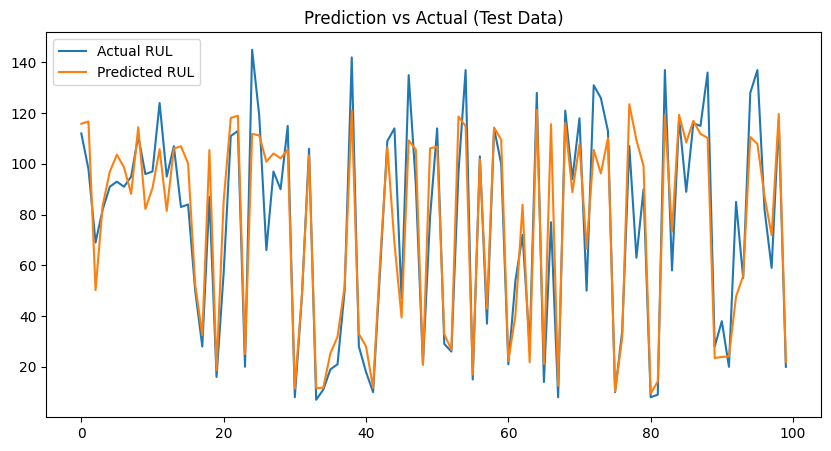

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual RUL")
plt.plot(pred1, label="Predicted RUL")
plt.legend()
plt.title("Prediction vs Actual (Test Data)")
plt.show()

Transformer

In [ ]:
pred2 = model2.predict(X_test)
pred2 = pred2.flatten()

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


In [ ]:
for i in range(5):
    print(f"Predicted: {pred2[i]:.2f}, Actual: {y_test[i]}")

Predicted: 102.42, Actual: 112
Predicted: 120.07, Actual: 98
Predicted: 44.02, Actual: 69
Predicted: 79.83, Actual: 82
Predicted: 113.63, Actual: 91


In [ ]:
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
print("Transformer RMSE:", rmse2)

Transformer RMSE: 15.026857364756683


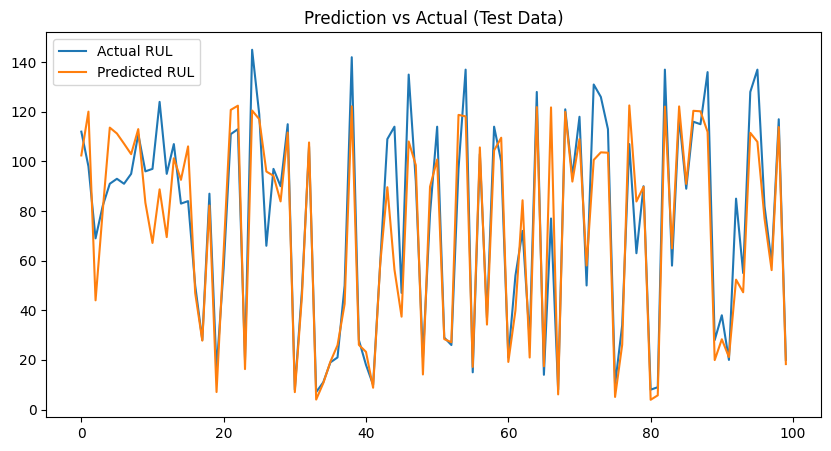

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual RUL")
plt.plot(pred2, label="Predicted RUL")
plt.legend()
plt.title("Prediction vs Actual (Test Data)")
plt.show()

#Model Comparison

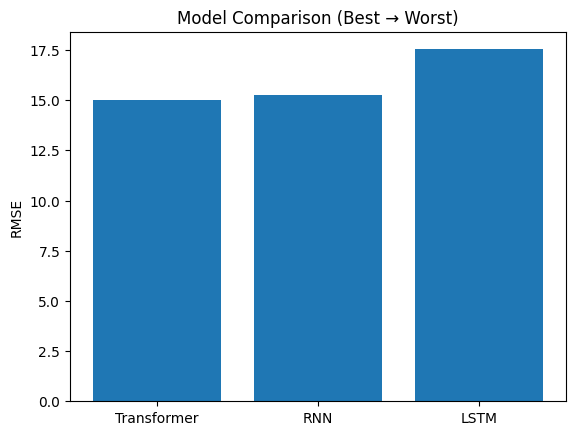

In [ ]:
models = np.array(["LSTM", "RNN", "Transformer"])
values = np.array([rmse, rmse1, rmse2])

idx = np.argsort(values)

models = models[idx]
values = values[idx]

plt.bar(models, values)
plt.title("Model Comparison (Best → Worst)")
plt.ylabel("RMSE")

plt.show()

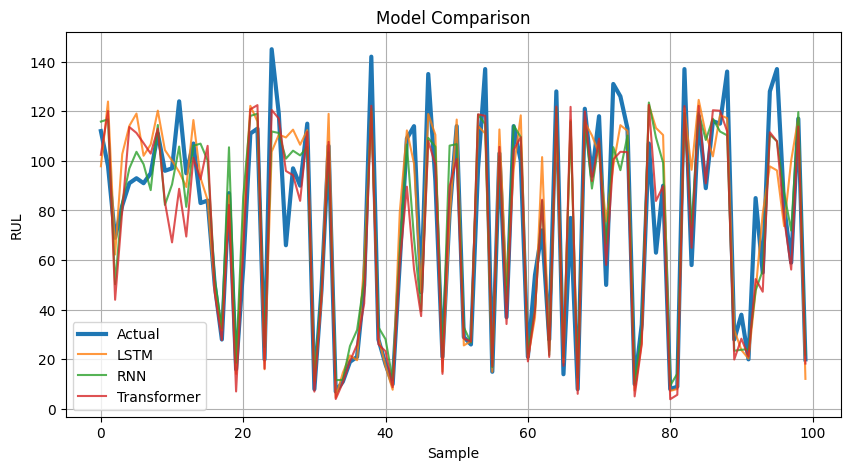

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", linewidth=3)
plt.plot(pred, label="LSTM", alpha=0.8)
plt.plot(pred1, label="RNN", alpha=0.8)
plt.plot(pred2, label="Transformer", alpha=0.8)

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Sample")
plt.ylabel("RUL")
plt.grid(True)
plt.show()

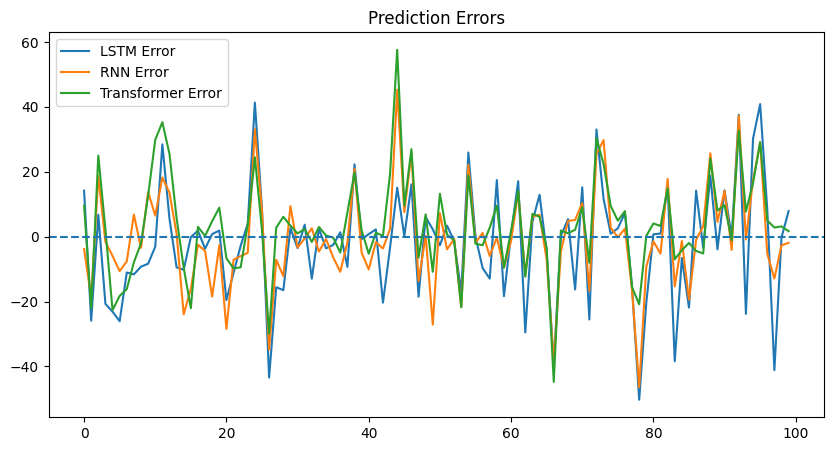

In [ ]:
err_lstm = y_test - pred
err_rnn = y_test - pred1
err_trans = y_test - pred2

plt.figure(figsize=(10,5))
plt.plot(err_lstm[:100], label="LSTM Error")
plt.plot(err_rnn[:100], label="RNN Error")
plt.plot(err_trans[:100], label="Transformer Error")

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Prediction Errors")
plt.show()

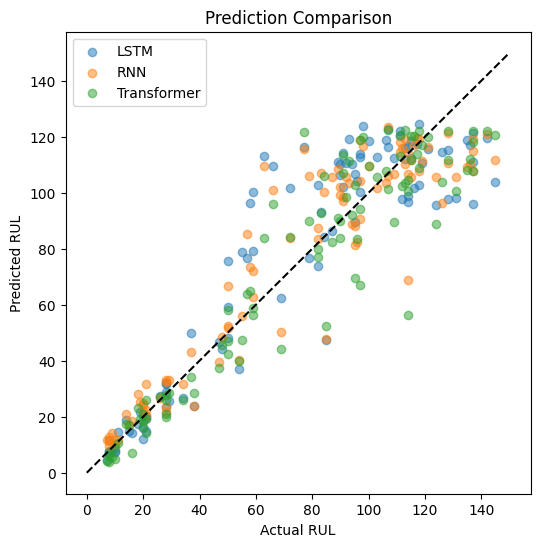

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, label="LSTM", alpha=0.5)
plt.scatter(y_test, pred1, label="RNN", alpha=0.5)
plt.scatter(y_test, pred2, label="Transformer", alpha=0.5)

plt.plot([0, 150], [0, 150], 'k--')

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.legend()
plt.title("Prediction Comparison")
plt.show()

In [ ]:
abs_err_lstm = np.abs(y_test - pred)
abs_err_rnn  = np.abs(y_test - pred1)
abs_err_trans = np.abs(y_test - pred2)

better = (abs_err_lstm < abs_err_rnn).mean()
print("LSTM better than RNN %:", better*100)

better = (abs_err_rnn < abs_err_lstm).mean()
print("RNN better than LSTM %:", better*100)

LSTM better than RNN %: 41.0
RNN better than LSTM %: 59.0
